# Deep Learning & ML Refresher

A short, concept-first refresher supporting the RoadFM-Lite thesis work (Sybil detection on VeReMi with a pretrained trajectory transformer).

**Contents**
1. Machine Learning Basics (§1)
2. Deep Learning in one picture (§2)
3. Activation Functions (§3)
4. Regularization & Generalization — over/underfitting, bias–variance, L1/L2, dropout, early stopping (§4–7)
5. Backpropagation — computational graph, forward/backward pass, autograd (§8–11)
6. Transformers — tokenization, embeddings, attention, encoder/decoder (§12–15)
7. Inference Engineering & KV Caching (§16)
8. **Model Evaluation** — precision/recall/F1, confusion matrix, cross-validation (§17)

> 💭 **Yo notebook kasari padhne:** harek section ko antya ma yesto 💭 block chha, jaha concept lai
> Nepali-English (Romanized) ma sajilo bhasa ma bujhaieko chha — formula bhanda pahila *thought* bujhna ko lagi.
> English section le "ke ho" bhanchha, 💭 block le "kina ho, kasto ho" bhanchha.


## 1. Machine Learning Basics

**Three learning regimes:**

| Regime | Signal | Example |
|---|---|---|
| Supervised | human-provided labels | classify a trajectory window as *benign* vs *Sybil* |
| Unsupervised | no labels — find structure | cluster trajectories by driving style |
| **Self-supervised (SSL)** | labels manufactured **from the data itself** | mask part of a trajectory, predict the masked part |

SSL is the core of this project: **RoadFM-Lite pretrains on unlabeled vehicle trajectories** (masked trajectory reconstruction + consistency prediction), so the expensive VeReMi attack labels are only needed for a small fine-tuning stage.

> 💭 **Nepali ma sochau:** Machine learning bhaneko rule haru hard-code garne hoina, data bata pattern **sikaune** tarika ho.
> - **Supervised** = teacher le answer sahit padhaune (yo trajectory "attack" ho bhanera label lagayeko chha).
> - **Unsupervised** = label chhaina, aafai group/pattern khoja.
> - **Self-supervised** = data **aafai bata** question-answer banaune. Hamro RoadFM-Lite le trajectory ko kehi timestep lukayera "yo masked part ke thiyo?" bhanera aafailai sodhchha — kunai manche le label lagaunai pardaina. Yehi bhayera 285,926 unlabeled window haru sabai training ma kaam lagchan.


### Train / Validation / Test

- **Train** — the only data the optimizer sees; gradients come from here.
- **Validation** — used to pick hyperparameters and to decide when to stop; never used for gradient updates.
- **Test** — touched **once**, at the end, to report honest numbers.

If validation choices leak into test (e.g. tuning until test F1 looks good), the reported numbers are optimistic fiction. In VeReMi this also means splitting by **vehicle/scenario groups**, not by random rows — otherwise windows from the same vehicle land in both train and test.

> 💭 **Analogy:** Train = padhne kitab, Validation = practice exam (yo herera padhne tarika milaune),
> Test = **final exam — ek choti matra**. Test set baar-baar herera model milayo bhane tyo aafailai dhoka ho:
> number ramro dekhincha tara naya data ma model bigrincha.
> **VeReMi ma extra danger:** euta gaadi (sender) ka overlapping window haru train ra test duitai ma pare bhane
> model le "yo gaadi chineko chhu" bhanera cheat garchha — tesaile hamro split **sender-level** chha (GroupShuffleSplit).


### Loss functions

A loss turns "how wrong is the model" into a single number to minimize.

- **MSE (regression / reconstruction):** $\mathcal{L}_{\text{MSE}} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2$ — used by RoadFM-Lite's masked trajectory *reconstruction* head.
- **Cross-entropy (classification):** $\mathcal{L}_{\text{CE}} = -\sum_{c} y_c \log \hat{p}_c$ — penalizes confident wrong predictions hardest; used for the Sybil-vs-benign and attack-type heads.

> 💭 **Loss bhaneko** "model kati galat chha" ko euta number ho — training bhaneko yo number ghatauney khel matra ho.
> Number predict garda (regression) **MSE**, class predict garda (classification) **cross-entropy**.
> Cross-entropy le confident-tara-galat prediction lai dherai thulo fine lagauchha — 99% sure bhanera galat bhannu
> bhanda 60% sure bhanera galat bhannu kam dandaniya chha. Model lai honest confidence sikaucha.


### Gradient descent

The whole training loop is: measure the loss, ask *"in which direction should each weight move to reduce it?"* (the gradient), and take a small step that way:

$$\theta \leftarrow \theta - \eta \, \nabla_{\theta}\mathcal{L}$$

where $\eta$ is the **learning rate** — too big diverges, too small crawls.

```mermaid
flowchart LR
    D[Data batch] --> M[Model f_theta]
    M --> P[Predictions]
    P --> L[Loss vs targets]
    L --> G[Gradients via backprop]
    G --> U[Update: theta = theta - lr * grad]
    U --> M
```

> 💭 **Pahad ko analogy:** kuhiro lageko pahad ma chhau, tala jaane bato dekhinna, tara khutta le slope feel
> garna sakchhau. Harek step ma sabai bhanda thado oralo (negative gradient) tira sano step chaal — yehi gradient descent ho.
> **Learning rate = step ko size:** dherai thulo bhaye valley naghera arko pattir pugchhau (loss uphrinchha),
> dherai sano bhaye pugna barsau lagchha. Tesaile schedule (warmup + decay) use garinchha.


## 2. Deep Learning in one picture

"Deep" = many layers, each transforming its input into a slightly more useful representation. Early layers learn simple patterns, later layers compose them — this is **representation learning**: instead of hand-designing features, the network learns them from data.

```mermaid
flowchart LR
    X[Input: raw features] --> H1[Hidden layer 1: simple patterns]
    H1 --> H2[Hidden layer 2: combinations]
    H2 --> H3[Hidden layer N: task-level concepts]
    H3 --> Y[Output: prediction]
```

For RoadFM-Lite: raw GPS/speed/heading sequences go in; the transformer layers build up a representation in which "physically implausible motion" (a Sybil signature) becomes easy to separate.

> 💭 **Deep ko matlab:** harek layer le input lai ali-ali transform gardai janchha. Suru ka layer le
> sana pattern samatchan (speed ko jump, direction change), pachhi ka layer le thula pattern (trajectory ko
> puraai shape, attack ko signature). Manually feature design garnu ko satta model **aafai representation sikchha** —
> yehi nai deep learning ko sabse thulo power ho, ani hamro thesis ko core bet pani: raw kinematics bata
> Sybil-relevant representation aafai niskanchha.


## 3. Activation Functions

**Why nonlinearity?** Stacking linear layers is pointless: $W_2(W_1 x) = (W_2 W_1)x$ — still one linear map, no matter how many layers. A nonlinearity between layers breaks this collapse and lets the network bend decision boundaries. No activation → a 100-layer net is exactly as expressive as 1-layer linear regression.

> 💭 **Kina nonlinearity?** Linear layer matra thupareko network jati thulo bhaye pani math le euta single
> linear function ma collapse huncha: $W_2(W_1x) = (W_2W_1)x$ — 100 layer = 1 layer, kunai faida chhaina.
> Activation function le harek layer pachhi "bend" dinchha — ani matra model le curve, circle, ra complex
> decision boundary haru sikna sakchha. Bina bend, sabai sidha line matra.


### The main activations

| Function | Formula | Used for | Known problem |
|---|---|---|---|
| **Sigmoid** | $\sigma(x)=\frac{1}{1+e^{-x}}$ | output layer for binary probability | saturates → **vanishing gradients**; not zero-centered |
| **Tanh** | $\tanh(x)$ | zero-centered hidden activation (older RNNs) | still saturates at both ends |
| **ReLU** | $\max(0,x)$ | default hidden activation in CNNs/MLPs — cheap, no saturation for $x>0$ | **dying ReLU**: a unit stuck at $x<0$ gets zero gradient forever |
| **LeakyReLU** | $\max(\alpha x, x)$, $\alpha\approx0.01$ | ReLU fix — small slope keeps dead units trainable | slope $\alpha$ is one more knob |
| **GELU** | $x\,\Phi(x)$ (Gaussian CDF gate) | **transformers** (BERT, GPT, RoadFM-Lite) — smooth ReLU-like | slightly costlier to compute |
| **Softmax** | $\frac{e^{x_i}}{\sum_j e^{x_j}}$ | turns a vector into a probability distribution (classifier output, **attention weights**) | not for hidden layers; sensitive to large logits |

> 💭 **Kun kahile?** **ReLU** = default: negative aaye 0, positive aaye tettikai — sasto ra bhayankar effective.
> **Sigmoid/tanh** = purano jamana, deep network ma gradient haraucha (vanishing).
> **GELU** = ReLU ko smooth bhai, transformer haru ma standard (RoadFM-Lite ma pani yehi).
> **Softmax** = last layer ma matra, raw score haru lai "kun class ho" ko probability ma badalna.


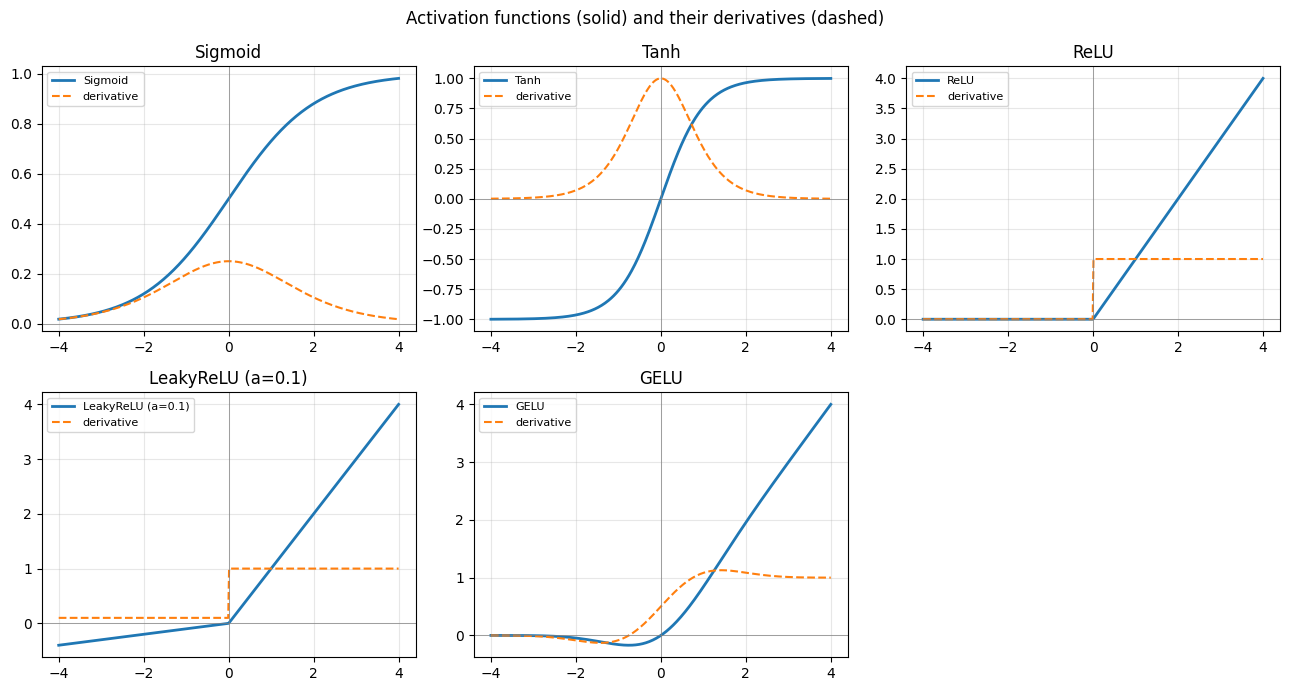

In [1]:
# Plot the activations and their derivatives (numpy only - no torch needed)
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 400)

def sigmoid(x): return 1 / (1 + np.exp(-x))
def d_sigmoid(x): s = sigmoid(x); return s * (1 - s)

def tanh(x): return np.tanh(x)
def d_tanh(x): return 1 - np.tanh(x) ** 2

def relu(x): return np.maximum(0, x)
def d_relu(x): return (x > 0).astype(float)

def leaky_relu(x, a=0.1): return np.where(x > 0, x, a * x)
def d_leaky_relu(x, a=0.1): return np.where(x > 0, 1.0, a)

def gelu(x):  # tanh approximation, as used in BERT/GPT
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x ** 3)))
def d_gelu(x, eps=1e-4):  # numeric derivative keeps the code short
    return (gelu(x + eps) - gelu(x - eps)) / (2 * eps)

funcs = [
    ("Sigmoid", sigmoid, d_sigmoid),
    ("Tanh", tanh, d_tanh),
    ("ReLU", relu, d_relu),
    ("LeakyReLU (a=0.1)", leaky_relu, d_leaky_relu),
    ("GELU", gelu, d_gelu),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (name, f, df) in zip(axes.flat, funcs):
    ax.plot(x, f(x), lw=2, label=name)
    ax.plot(x, df(x), "--", lw=1.5, label="derivative")
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
    ax.set_title(name); ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes.flat[-1].axis("off")  # unused 6th panel
fig.suptitle("Activation functions (solid) and their derivatives (dashed)")
fig.tight_layout()
plt.show()


**Reading the plot:** sigmoid/tanh derivatives collapse to ~0 outside a narrow band — that is the vanishing-gradient zone. ReLU's derivative is a clean 0/1 step (fast, but dead at $x<0$); LeakyReLU patches the dead zone; GELU is the smooth compromise transformers use.

> 💭 **Graph bata bujhne:** sigmoid ko derivative (dashed line) beech ko sano band ma matra jiudo chha —
> deep network ma yo sano number haru multiply hudai gayera gradient shunya tira haraucha.
> ReLU ko derivative positive side ma thyakkai 1 chha — gradient bina ghateko tala samma pugchha.
> Yehi ek ta karan le modern deep network haru train huna sambhav bhayo.


## 4. Underfitting, Overfitting, Bias & Variance

**Underfitting** — the model is too simple to capture the pattern; it is wrong on the training data *and* on new data.

**Overfitting** — the model memorizes the training data (including its noise); it looks great on training data but fails on new data.

**Bias** is error from wrong assumptions (too-simple model). **Variance** is error from sensitivity to the particular training sample (too-flexible model). For squared error the expected test error decomposes as:

$$\text{Total error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible noise}$$

You cannot shrink the noise term — the game is trading bias against variance.

> 💭 **Vidyarthi ko analogy:**
> - **Underfitting** = kam padheko vidyarthi — training (practice) ma pani fail, test ma pani fail. Model dherai simple chha.
> - **Overfitting** = ratta lagaune (memorize garne) vidyarthi — practice question ma perfect, tara naya question aayo bhane atkinchha.
> - **Bias** = model dherai simple bhayera hune *systematic* galti. **Variance** = training data ali farak huda model *dherai badline* problem.
> Hamile khojne beech ko sweet spot ho: concept **bujheko** vidyarthi, jasle naya question pani solve garchha.


As model complexity grows, bias falls but variance rises — the sweet spot is in between:

```mermaid
graph LR
    A[Low complexity<br/>e.g. linear model] -->|add capacity| B[Sweet spot<br/>bias and variance balanced]
    B -->|add more capacity| C[High complexity<br/>e.g. degree-15 poly]
    A -. "high bias, low variance<br/>UNDERFIT" .-> A
    C -. "low bias, high variance<br/>OVERFIT" .-> C
```

**Diagnosing from train vs. validation error:**

| Train error | Validation error | Diagnosis | Fix |
|---|---|---|---|
| High | High (similar) | **Underfitting** (high bias) | Bigger model, more features, train longer |
| Low | High (big gap) | **Overfitting** (high variance) | More data, regularization, dropout, early stopping |
| Low | Low | Good fit | Ship it |

> 💭 **Diagnosis sutra (yaad rakhne):** train error **thulo** → underfit (model thulo banau, dherai train gara, feature thapa).
> Train error **sano** tara val error **thulo** → overfit (regularization, dropout, dherai data, sano model).
> Duitai sano → ramro chha! Duitai herera matra decide garne — euta number le kahilei purai katha bhandaina.


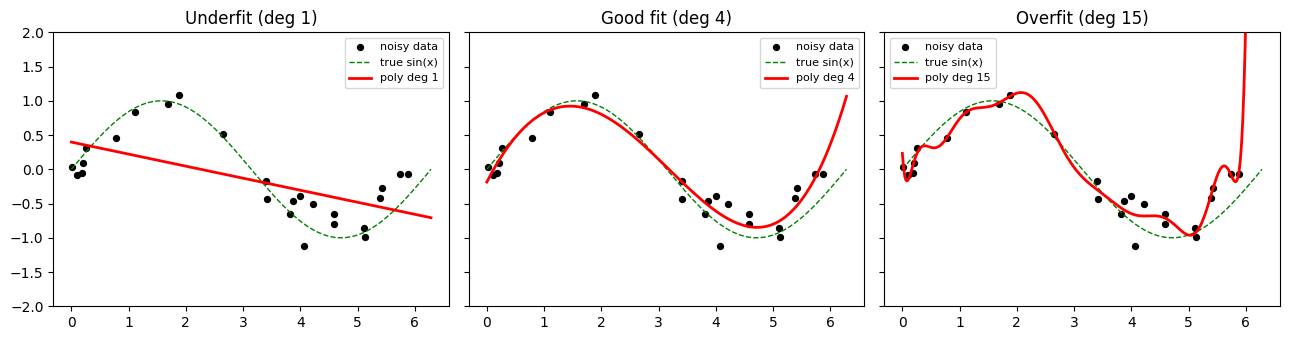

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0, 2 * np.pi, 25))
y = np.sin(x) + rng.normal(0, 0.25, x.size)          # noisy sine
xs = np.linspace(0, 2 * np.pi, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, deg, title in zip(axes, [1, 4, 15],
                          ["Underfit (deg 1)", "Good fit (deg 4)", "Overfit (deg 15)"]):
    coeffs = np.polyfit(x, y, deg)
    ax.scatter(x, y, s=18, color="k", label="noisy data")
    ax.plot(xs, np.sin(xs), "g--", lw=1, label="true sin(x)")
    ax.plot(xs, np.polyval(coeffs, xs), "r", lw=2, label=f"poly deg {deg}")
    ax.set_title(title); ax.set_ylim(-2, 2); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Regularization: L1 and L2

Overfitting usually shows up as **large, wildly-tuned weights**. Regularization fights it by adding a penalty on weight size to the loss, so the model must justify every bit of complexity.

**L2 (ridge / weight decay):**
$$L_{\text{total}} = L_{\text{data}} + \lambda \sum_i w_i^2$$
Shrinks all weights *smoothly* toward zero (rarely exactly zero). This is the "weight decay" knob in optimizers like AdamW.

**L1 (lasso):**
$$L_{\text{total}} = L_{\text{data}} + \lambda \sum_i |w_i|$$
Drives many weights to **exactly zero** → sparse models, built-in feature selection.

**Geometric intuition:** minimizing the data loss subject to a weight budget means finding where the loss contours first touch the constraint region. The L1 region is a **diamond** — contours usually hit it at a corner, where some coordinates are exactly zero. The L2 region is a **circle** — contact happens at a smooth point, so weights shrink but stay nonzero.

> 💭 **Regularization = complexity ko fine (jariwana).** Model lai bhanne: "data fit gara, tara weight haru
> dherai thulo nabanau." **L2** le thula weight haru lai sano banauchha (smooth solution) — weight decay bhanera
> transformer training ma sadhai hunchha. **L1** le kaam nalagne weight haru lai **thyakkai 0** banaidinchha —
> free ma feature selection! $\lambda$ = fine ko rate: dherai thulo → underfit, dherai sano → fine ko kunai asar chhaina.
> Geometric intuition: L1 ko constraint diamond ko kuna haru axis ma parchan — tesaile solution sparse (0 haru bhayeko) hunchha.


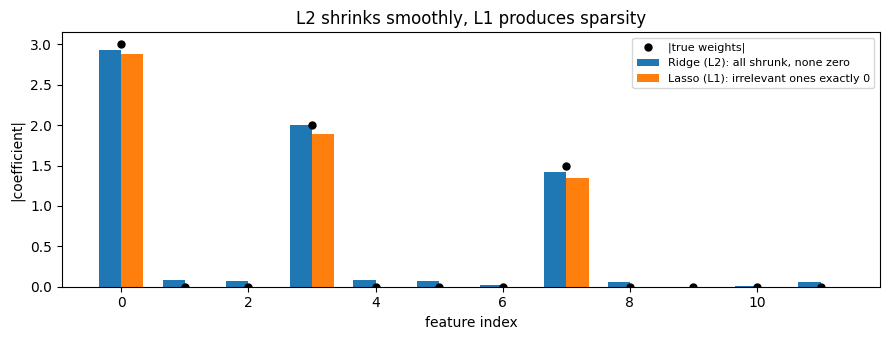

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

# Synthetic regression: only 3 of 12 features actually matter
rng = np.random.default_rng(1)
n, d = 100, 12
X = rng.normal(size=(n, d))
true_w = np.zeros(d); true_w[[0, 3, 7]] = [3.0, -2.0, 1.5]
y = X @ true_w + rng.normal(0, 0.5, n)

ridge = Ridge(alpha=1.0).fit(X, y)
lasso = Lasso(alpha=0.1).fit(X, y)

idx = np.arange(d); w = 0.35
plt.figure(figsize=(9, 3.5))
plt.bar(idx - w/2, np.abs(ridge.coef_), width=w, label="Ridge (L2): all shrunk, none zero")
plt.bar(idx + w/2, np.abs(lasso.coef_), width=w, label="Lasso (L1): irrelevant ones exactly 0")
plt.scatter(idx, np.abs(true_w), color="k", zorder=3, s=25, label="|true weights|")
plt.xlabel("feature index"); plt.ylabel("|coefficient|")
plt.title("L2 shrinks smoothly, L1 produces sparsity")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 6. Dropout

At **training time**, randomly zero each unit's activation with probability $p$ (a fresh random mask every batch). With *inverted dropout* the survivors are scaled by $\frac{1}{1-p}$ during training, so at **inference time you do nothing** — the full network runs as-is.

**Why it works:**
- **Ensemble intuition** — every batch trains a different random sub-network; inference approximates averaging that huge ensemble.
- **Prevents co-adaptation** — a unit can't rely on one specific partner neuron always being there, so each learns independently useful features.

Typical values: $p = 0.1$–$0.3$ for transformers, up to $0.5$ for big fully-connected layers. In transformers dropout is applied to the **attention weights** and inside the **feed-forward (FFN) blocks** (plus on embeddings/residuals).

> 💭 **Dropout = random neuron lai "aaja timi chutti" bhanne.** Training ma harek pass ma kehi neuron
> (p ≈ 0.1–0.5) off garinchha. Kina kaam garchha? Neuron haru le euta-arko ma bharosa garna paudainan —
> harek aafai useful hunu parchha. Team ko analogy: random member absent huda pani kaam chalna parchha bhane
> sabai le sabai kura sikchan, kohi pani "irreplaceable" hudaina.
> Test time ma sabai neuron on hunchan (inverted dropout le scale milauchha).
> RoadFM-Lite ma dropout 0.1 chha — attention weight ra FFN duitai ma.


```mermaid
graph LR
    subgraph Input layer
        x1((x1)); x2((x2)); x3((x3))
    end
    subgraph Hidden layer with dropout
        h1((h1)); h2(("h2 ✗")); h3((h3)); h4(("h4 ✗"))
    end
    o((y))
    x1 --> h1; x1 --> h3
    x2 --> h1; x2 --> h3
    x3 --> h1; x3 --> h3
    h1 --> o; h3 --> o
    style h2 fill:#f6b0b0,stroke-dasharray: 4 4
    style h4 fill:#f6b0b0,stroke-dasharray: 4 4
```

Crossed-out units (h2, h4) are dropped for this batch — their activations are zeroed and they pass nothing forward.

## 7. Early Stopping

Train error keeps falling forever, but **validation error follows a U-shape**: it falls while the model learns signal, then rises once the model starts memorizing noise. Early stopping simply halts at the bottom of the U.

Recipe:
1. After each epoch, evaluate on the validation set.
2. If val loss improved → save a checkpoint, reset the patience counter.
3. If not → increment the counter; once it exceeds `patience` epochs, stop.
4. Restore the **best** checkpoint, not the last one.

It's *implicit regularization*: fewer gradient steps keep the weights closer to their small initialization — a similar effect to L2, and it costs nothing extra.

> 💭 **Early stopping = "aba rok, yo bhanda ramro hudaina" bhanne buddhi.** Train loss ta sadhai ghatirahanchha
> (model le ratta lagauna thalchha), tara validation loss euta bindu pachhi **badhna** thalchha — tyahi rok.
> **Patience** = kati epoch samma sudhar parkhane bhanne dhairya (e.g. 10). Sudhar bhayena bhane roka ani
> **sabse ramro checkpoint** ma farka. Yo free ko regularization ho — extra compute chaidaina, baru ghatai hunchha.


```mermaid
flowchart TD
    A[Train one epoch] --> B[Evaluate val loss]
    B --> C{Improved?}
    C -- yes --> D[Save checkpoint<br/>patience = 0]
    C -- no --> E[patience += 1]
    D --> F{patience > limit?}
    E --> F
    F -- no --> A
    F -- yes --> G[Stop — restore best checkpoint]
```

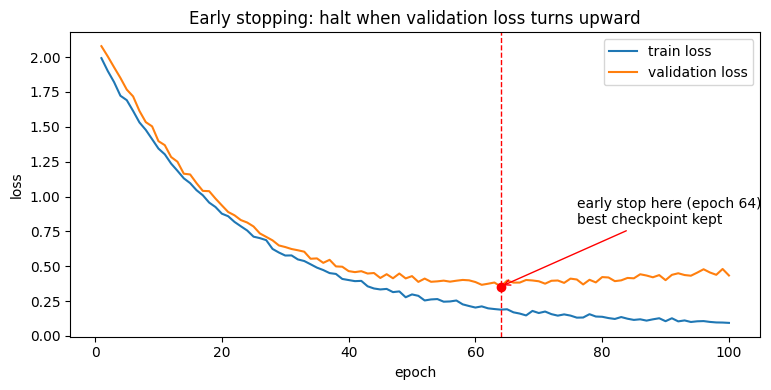

In [4]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 101)
rng = np.random.default_rng(2)
train_loss = 2.0 * np.exp(-epochs / 22) + 0.08 + rng.normal(0, 0.01, epochs.size)
# val loss: falls, then rises again as overfitting begins
val_loss = 2.0 * np.exp(-epochs / 20) + 0.20 + 0.004 * np.maximum(epochs - 38, 0) \
           + rng.normal(0, 0.015, epochs.size)

best = int(np.argmin(val_loss))
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss, label="train loss")
plt.plot(epochs, val_loss, label="validation loss")
plt.axvline(epochs[best], color="r", ls="--", lw=1)
plt.scatter([epochs[best]], [val_loss[best]], color="r", zorder=3)
plt.annotate(f"early stop here (epoch {epochs[best]})\nbest checkpoint kept",
             xy=(epochs[best], val_loss[best]),
             xytext=(epochs[best] + 12, val_loss[best] + 0.45),
             arrowprops=dict(arrowstyle="->", color="r"))
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Early stopping: halt when validation loss turns upward")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Neural Networks & the Computational Graph

A single **neuron** computes a weighted sum followed by a nonlinearity:

$$z = Wx + b, \qquad a = \sigma(z)$$

A **neural network** is just a *composition of such functions* — layer after layer:
$f(x) = f_L(\dots f_2(f_1(x)))$. Stacking linear maps alone would collapse into one linear map;
the activations in between are what give the network its expressive power.

A **computational graph** breaks this composition into primitive operations (matmul, add, ReLU,
softmax, loss), each a node with inputs and one output. Once the function is written as a graph,
computing derivatives becomes *mechanical*: every node only needs to know its own local derivative.

Forward graph for a 2-layer classifier:

```mermaid
graph LR
    x["x (input)"] --> m1["W1·x + b1"]
    p1["W1, b1"] --> m1
    m1 -- "z1" --> relu["ReLU"]
    relu -- "a1" --> m2["W2·a1 + b2"]
    p2["W2, b2"] --> m2
    m2 -- "z2 (logits)" --> sm["softmax"]
    sm -- "p" --> L["cross-entropy loss L"]
    ylab["y (true label)"] --> L
```

> 💭 **Neuron = weighted sum + activation. Tettikai ho.** Network = yesta neuron haru ko layer-by-layer chain.
> **Computational graph** = puraai calculation lai sana-sana step (node) ma tukraune tarika.
> Kina tukraune? Kinaki harek sano step ko derivative **sajilo** chha (multiply, add, ReLU — sabai ko local
> derivative 1-line ko chha), ani chain rule le ti sabai lai jodera jasto sukai complex function ko gradient
> nikalna sakinchha. Complexity lai assembly line ma badalne trick ho yo.


## 9. Forward Pass

The forward pass simply evaluates the graph **left to right**: feed in $x$, compute $z_1$, then
$a_1$, then the logits $z_2$, then the softmax probabilities $p$, and finally the loss $L$.
Crucially, we **cache every intermediate value** ($z_1$, $a_1$, $p$) as we go — the backward pass
will need exactly these cached activations to compute gradients. This is why training uses more
memory than inference: the whole trail of intermediates must be kept alive until backprop consumes
them. Follow the arrows in the diagram above — that *is* the forward pass.

> 💭 **Forward pass = graph lai baya bata daya evaluate garne:** input hala, layer-by-layer hisab garndai ja,
> output ra loss nikala. **Euta kura yaad rakha:** beech ka activation haru **cache** garnu parchha —
> backward pass lai tinai chahinchha. Training ma GPU memory kina bharincha? Yehi cache le garda.
> (Inference ma cache chaidaina — tesaile inference sasto chha.)


## 10. Backward Pass & Backpropagation

Backpropagation is the **chain rule applied to the graph, right to left**. Each node receives the
*upstream* gradient (how much the loss changes with its output) and multiplies it by its own
**local derivative** — nothing more. No node needs global knowledge of the network.

For the 2-layer net, the gradient of the loss w.r.t. the first-layer weights unrolls as:

$$
\frac{\partial L}{\partial W_1}
= \frac{\partial L}{\partial z_2}\cdot
  \frac{\partial z_2}{\partial a_1}\cdot
  \frac{\partial a_1}{\partial z_1}\cdot
  \frac{\partial z_1}{\partial W_1}
$$

with the pleasantly simple pieces (for softmax + cross-entropy):

$$
\frac{\partial L}{\partial z_2} = p - y,\qquad
\frac{\partial z_2}{\partial a_1} = W_2^\top,\qquad
\frac{\partial a_1}{\partial z_1} = \mathbb{1}[z_1 > 0],\qquad
\frac{\partial z_1}{\partial W_1} = x^\top
$$

Gradients flowing backward through the same graph:

```mermaid
graph RL
    L["L (loss), seed grad = 1"] -- "dL/dp" --> sm["softmax"]
    sm -- "dL/dz2 = p − y" --> m2["W2·a1 + b2"]
    m2 -- "dL/dW2 = a1ᵀ (p − y)" --> p2["update W2, b2"]
    m2 -- "dL/da1 = (p − y) W2ᵀ" --> relu["ReLU"]
    relu -- "dL/dz1 = dL/da1 ⊙ 1[z1&gt;0]" --> m1["W1·x + b1"]
    m1 -- "dL/dW1 = xᵀ dL/dz1" --> p1["update W1, b1"]
```

> 💭 **Backprop = chain rule, daya bata baya.** Harek node le duita kura matra jaanchha:
> (1) aafno **local derivative** (2) mathi bata aayeko **upstream gradient**. Duitai multiply garyo, tala pathayo — bas.
> Yehi simple rule harek node ma dohoryayo bhane jati thulo network ko pani gradient niskanchha.
> Magic hoina — calculus ko assembly line ho. Formula ma haraye pahila diagram ko arrow haru follow gara.


### Vanishing & exploding gradients

Because backprop *multiplies* local derivatives along the path, deep chains of small factors shrink
the gradient exponentially (vanishing) and chains of large factors blow it up (exploding). Sigmoid
is the classic culprit: its derivative peaks at $0.25$ and is nearly $0$ for saturated inputs, so a
deep stack of sigmoids leaves early layers with essentially no learning signal — they "die". Modern
fixes attack the product structure directly: **ReLU** has derivative exactly $1$ on its active
half, **residual connections** add an identity path so gradients can skip multiplications entirely,
and **normalization layers** (BatchNorm / LayerNorm) keep pre-activations in the well-behaved,
non-saturated regime.

> 💭 **Gradient haraune/padkine samasya:** backprop le layer-pichhe derivative haru **multiply** garchha.
> 0.9 lai 50 choti multiply → lagbhag 0 (**vanishing** — suru ka layer le kehi sikdainan).
> 1.1 lai 50 choti → visphot (**exploding** — training NaN ma jaanchha).
> Samadhan: ReLU (derivative 1), **residual connection** (gradient ko highway — layer skip garera sidha bagchha),
> normalization (LayerNorm). Transformer ma yi tinai chhan — tesaile 100+ layer pani train hunchha.


### Demo: a 2-layer MLP with hand-written backprop

Everything above, in ~60 lines of numpy: two-moons toy data, explicit `forward()` and
`backward()`, gradient descent, and the learned decision boundary. Every gradient line below
corresponds one-to-one to an arrow in the backward diagram.

> 💭 Tala ko code ma mathi ka sabai formula **numpy ma haat le** lekhieka chhan — torch chhaina, autograd chhaina.
> Shape comment haru (`(n, 2) @ (2, 16) -> (n, 16)`) dhyan diyera padha — backprop bujhne sabse chhito bato
> shape haru track garnu ho. Harek `d`-variable (`dW1`, `dz1`...) = "loss ko tyo cheez pratiko gradient".


epoch   0   loss 0.8042   acc 0.532
epoch  40   loss 0.3573   acc 0.860
epoch  80   loss 0.2257   acc 0.905
epoch 120   loss 0.1375   acc 0.940
epoch 160   loss 0.0907   acc 0.975
epoch 200   loss 0.0732   acc 0.978
epoch 240   loss 0.0661   acc 0.978
epoch 280   loss 0.0621   acc 0.978
epoch 320   loss 0.0594   acc 0.975
epoch 360   loss 0.0574   acc 0.978
epoch 400   loss 0.0558   acc 0.978


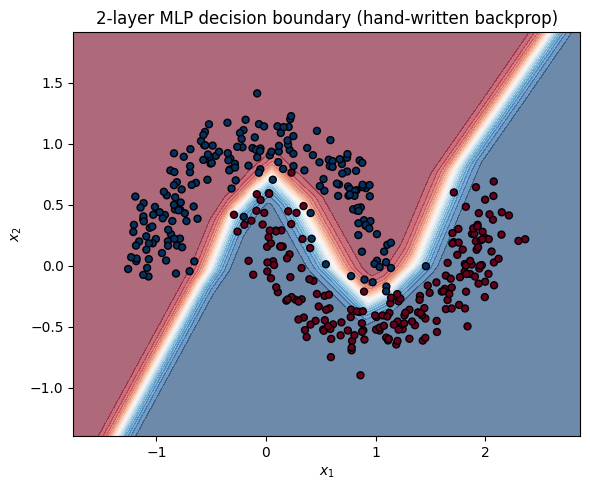

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

def make_moons(n=400, noise=0.15):
    n2 = n // 2
    t = rng.uniform(0, np.pi, n2)
    upper = np.c_[np.cos(t), np.sin(t)]
    lower = np.c_[1 - np.cos(t), 0.5 - np.sin(t)]
    X = np.vstack([upper, lower]) + rng.normal(0, noise, (n, 2))
    y = np.r_[np.zeros(n2, int), np.ones(n2, int)]
    return X, y

X, y = make_moons()
N, D, H, C = len(X), 2, 16, 2          # samples, input dim, hidden, classes
Y = np.eye(C)[y]                       # one-hot labels          (N, C)

W1 = rng.normal(0, 0.5, (D, H)); b1 = np.zeros(H)
W2 = rng.normal(0, 0.5, (H, C)); b2 = np.zeros(C)

def forward(X):
    z1 = X @ W1 + b1                   # pre-activation          (N, H)
    a1 = np.maximum(z1, 0)             # ReLU                    (N, H)
    z2 = a1 @ W2 + b2                  # logits                  (N, C)
    z2 = z2 - z2.max(axis=1, keepdims=True)          # numerical stability
    p = np.exp(z2) / np.exp(z2).sum(axis=1, keepdims=True)  # softmax (N, C)
    return z1, a1, p                   # cache z1, a1 for backward

def backward(X, Y, z1, a1, p):
    n = len(X)
    dz2 = (p - Y) / n                  # dL/dz2 = p - y          (N, C)
    dW2 = a1.T @ dz2                   # dL/dW2                  (H, C)
    db2 = dz2.sum(axis=0)              #                         (C,)
    da1 = dz2 @ W2.T                   # dL/da1                  (N, H)
    dz1 = da1 * (z1 > 0)               # ReLU local grad         (N, H)
    dW1 = X.T @ dz1                    # dL/dW1                  (D, H)
    db1 = dz1.sum(axis=0)              #                         (H,)
    return dW1, db1, dW2, db2

lr = 1.5
for epoch in range(401):
    z1, a1, p = forward(X)
    loss = -np.log(p[np.arange(N), y] + 1e-12).mean()
    dW1, db1, dW2, db2 = backward(X, Y, z1, a1, p)
    W1 -= lr * dW1; b1 -= lr * db1     # gradient descent step
    W2 -= lr * dW2; b2 -= lr * db2
    if epoch % 40 == 0:
        acc = (p.argmax(1) == y).mean()
        print(f"epoch {epoch:3d}   loss {loss:.4f}   acc {acc:.3f}")

# decision boundary
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, 200),
                     np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, 200))
_, _, pg = forward(np.c_[xx.ravel(), yy.ravel()])
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, pg[:, 1].reshape(xx.shape), levels=20, cmap="RdBu", alpha=0.6)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolors="k", s=25)
plt.title("2-layer MLP decision boundary (hand-written backprop)")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.tight_layout(); plt.show()

## 11. What Autograd Frameworks Do

PyTorch, JAX, and TensorFlow automate exactly the two functions we just wrote by hand. As your
code runs, the framework records every primitive operation into a computational graph (PyTorch
calls this the *tape*); each primitive ships with its local derivative built in. Calling
`loss.backward()` walks that graph right-to-left, multiplying upstream gradients by local ones —
the identical chain-rule mechanics as our `backward()` — and deposits the results in each
parameter's `.grad`. That's all "autograd" is: automatic bookkeeping of the graph plus a library
of local derivatives, which is why understanding the 60 lines above means you understand what
every deep-learning framework does under the hood.

> 💭 **PyTorch le yehi kaam automatic garchha:** timi forward matra lekhchhau, PyTorch le pachhadi
> computational graph banauchha, ani `loss.backward()` bhanne bittikai chain rule daya-bata-baya chalauchha.
> Hamile mathi 60 line ma haat le gareko kaam autograd le crores of parameters ma millisecond ma garchha.
> Tara bhitra bhaeko kura **thyakkai yehi** ho — tesaile yo section bujhyo bhane `loss.backward()` kahilei mystery hudaina.


# Part 4 — Transformers ("Attention Is All You Need") & Inference Engineering

A short refresher on the transformer architecture (Vaswani et al., 2017) and how transformers are served efficiently at inference time — with notes on how each idea maps to **RoadFM-Lite**.

## 12. Tokenization

A language model can't read raw text — it reads **integer ids**. Tokenization is the mapping:

> text → tokens → integer ids, e.g. `"unhappiness"` → `["un", "happi", "ness"]` → `[512, 8071, 921]`

**Word-level** tokenization (one id per word) gives huge vocabularies and can't handle unseen words. **Subword** tokenization (BPE — Byte-Pair Encoding) fixes both. BPE intuition in three sentences: start with a vocabulary of single characters; repeatedly find the most frequent adjacent pair of symbols in the training corpus and merge it into one new symbol; stop when the vocabulary reaches the desired size. Frequent words end up as single tokens, rare words decompose into meaningful subword pieces, and *any* string can always be tokenized.

**RoadFM-Lite note:** our "tokens" are not text — each token is one **trajectory time-step** (a vector of 13 kinematic features: position, speed, acceleration, heading, ...). Sequences of continuous vectors don't need a tokenizer or an embedding lookup table; instead a **linear projection** maps each 13-dim step to the model dimension $d_{model}$.

> 💭 **Tokenization = text lai number ma badalne.** Model le akshar bujhdaina, integer id matra bujhchha.
> BPE = frequent pair haru jodhdai vocabulary banaune chalak tarika ("un" + "happy" jasto subword haru).
> **TARA hamro RoadFM-Lite ma text nai chhaina** — trajectory ko harek timestep nai euta "token" ho:
> 13 features (pos, spd, acl, hed, dt, dpos, dspd) ko continuous vector. Vocabulary chaidaina,
> embedding lookup ko satta **linear projection** chha: 13-dim → 128-dim. Sequence modeling ko machinery
> chai ustai — tesaile transformer trajectory ma pani kaam garchha.


## 13. Embeddings & Positional Encoding

**Embedding** = a learned lookup table: token id $i$ → a dense vector $E_i \in \mathbb{R}^{d_{model}}$. The vector is trained like any other weight, and similar tokens end up with similar vectors.

**Why positions must be injected:** self-attention is a weighted sum over the whole sequence — it is **permutation-invariant**. Shuffle the tokens and attention produces the same set of outputs. So we must add position information explicitly.

**Sinusoidal positional encoding** (the original paper):

$$PE_{(pos,\,2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right), \qquad PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Each dimension oscillates at a different frequency, so every position gets a unique "barcode", and relative offsets are linear functions of the encodings — no training required, and it extrapolates to unseen lengths.

**Learned PE** (BERT-style): just another embedding table indexed by position — simpler, often equally good, but fixed to the max length seen in training. RoadFM-Lite windows are a fixed 20 steps, so either choice works.

> 💭 **Embedding = harek token ko learned "meaning vector".** Positional encoding kina chahiyo?
> Attention le **order dekhdaina** — "Ram le Shyam lai hane" ra "Shyam le Ram lai hane" uslai same lagchha!
> Sin/cos wave haru (farak-farak frequency ka) le harek position lai unique signature dinchan, ani nearby
> position haru ko signature milto-julto hunchha (relative distance sikha sajilo).
> RoadFM-Lite ma 20 timestep ko lagi sinusoidal PE chha — trajectory ma "kun step pahila aayo" critical chha,
> kinaki replay attack ko signature **temporal order** mai lukeko hunchha.


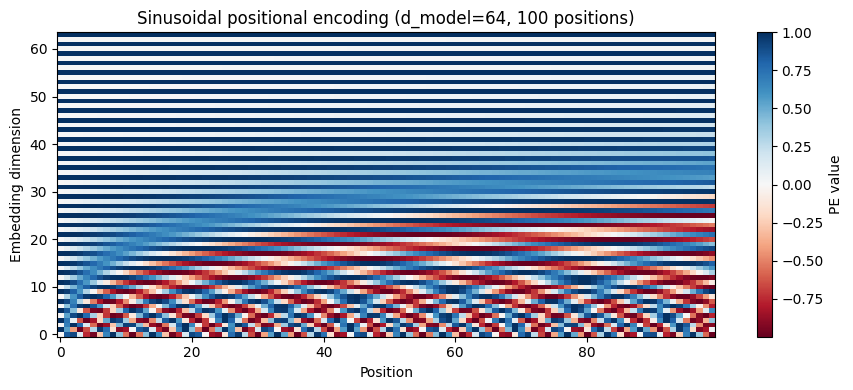

In [6]:
import numpy as np
import matplotlib.pyplot as plt

d_model, n_pos = 64, 100
pos = np.arange(n_pos)[:, None]              # (100, 1)
i = np.arange(d_model // 2)[None, :]         # (1, 32)
angles = pos / (10000 ** (2 * i / d_model))  # (100, 32)

pe = np.zeros((n_pos, d_model))
pe[:, 0::2] = np.sin(angles)
pe[:, 1::2] = np.cos(angles)

plt.figure(figsize=(9, 4))
plt.imshow(pe.T, aspect="auto", cmap="RdBu", origin="lower")
plt.colorbar(label="PE value")
plt.xlabel("Position")
plt.ylabel("Embedding dimension")
plt.title("Sinusoidal positional encoding (d_model=64, 100 positions)")
plt.tight_layout()
plt.show()
# Low dims oscillate fast, high dims slowly -> each position gets a unique pattern.

## 14. Attention: Query, Key, Value

Plain words first: every token asks **"who in this sequence is relevant to me?"** Each token emits a **query** (what I'm looking for), a **key** (what I offer for matching), and a **value** (the content I contribute). Relevance = dot product of my query with everyone's keys; softmax turns those scores into weights; my new representation is the **weighted sum of everyone's values**.

**Scaled dot-product attention:**

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V$$

where $Q = XW_Q$, $K = XW_K$, $V = XW_V$ are linear projections of the input $X$.

**Why the $\sqrt{d_k}$ scaling?** Dot products of random $d_k$-dim vectors have variance $\propto d_k$. For large $d_k$ the raw scores get huge, softmax saturates to near one-hot, and gradients vanish. Dividing by $\sqrt{d_k}$ keeps score variance ≈ 1 so softmax stays in a well-behaved regime.

**Multi-head attention:** instead of one attention over $d_{model}$ dims, run $h$ attentions in parallel, each on a $d_{model}/h$-dim subspace ("head"). Each head can specialize (one tracks nearby steps, another long-range dependencies); the head outputs are concatenated and mixed by a final projection $W_O$.

> 💭 **Attention ko core idea ek line ma:** harek token le sodhchha — *"yo sequence ma mero lagi ko relevant chha?"*
> - **Query (Q)** = mero khoj ("ma pronoun hu, mero subject khojdai chhu")
> - **Key (K)** = harek token ko nameplate ("ma noun hu", "ma verb hu")
> - **Value (V)** = tyo token ko actual content.
> Q·K = kati match bhayo (score) → softmax le weight → Value haru ko **weighted average**.
> **√dk le kina divide?** Dimension thulo huda dot product ko value thulo hunchha, softmax saturate hunchha
> (winner-takes-all), gradient haraucha. √dk le score haru lai "temperature" milaidinchha.
> **Multi-head** = yehi khel 8 choti parallel, farak-farak subspace ma — euta head le syntax hercha,
> arko le distance, arko le velocity consistency (hamro case ma).


```mermaid
flowchart LR
    X["Input X"] --> WQ["Wq"] --> Q["Q"]
    X --> WK["Wk"] --> K["K"]
    X --> WV["Wv"] --> V["V"]
    Q --> S["scores = QK^T / sqrt(dk)"]
    K --> S
    S --> SM["softmax"]
    SM --> WS["weighted sum of V"]
    V --> WS
    WS --> CAT["concat h heads"]
    CAT --> WO["Wo"] --> OUT["Output"]
```

Attention weights (rows sum to 1):
[[0.164 0.14  0.309 0.234 0.154]
 [0.451 0.062 0.094 0.058 0.335]
 [0.248 0.172 0.175 0.196 0.209]
 [0.215 0.181 0.221 0.145 0.238]
 [0.336 0.056 0.238 0.106 0.264]]
Row sums: [1. 1. 1. 1. 1.]


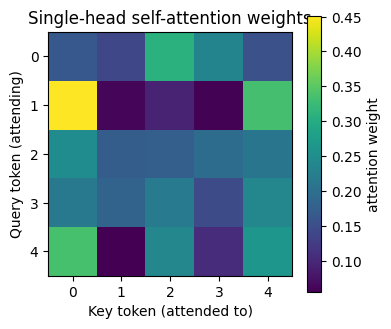

In [7]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n_tokens, d = 5, 8                       # tiny toy sequence
X = rng.normal(size=(n_tokens, d))

Wq, Wk, Wv = (rng.normal(size=(d, d)) / np.sqrt(d) for _ in range(3))
Q, K, V = X @ Wq, X @ Wk, X @ Wv

scores = Q @ K.T / np.sqrt(d)            # (5, 5) relevance scores
weights = np.exp(scores - scores.max(axis=-1, keepdims=True))
weights /= weights.sum(axis=-1, keepdims=True)   # softmax rows
out = weights @ V                        # each token = weighted mix of values

print("Attention weights (rows sum to 1):")
print(np.round(weights, 3))
print("Row sums:", weights.sum(axis=-1).round(3))

plt.figure(figsize=(4, 3.5))
plt.imshow(weights, cmap="viridis")
plt.colorbar(label="attention weight")
plt.xlabel("Key token (attended to)")
plt.ylabel("Query token (attending)")
plt.title("Single-head self-attention weights")
plt.tight_layout()
plt.show()

## 15. Encoder & Decoder

**Encoder block anatomy** (repeated $N$ times):

1. **Self-attention** — every token attends to every token (bidirectional).
2. **Add & Norm** — residual connection ($x + \mathrm{Sublayer}(x)$) then LayerNorm. Residuals keep gradients flowing through deep stacks; LayerNorm stabilizes activations.
3. **Feed-forward network (FFN)** — a 2-layer MLP applied to each position independently (expand to ~4× $d_{model}$, nonlinearity, project back).
4. **Add & Norm** again.

**Decoder block** adds two things: its self-attention is **causally masked** (a token may only attend to earlier positions — no peeking at the future it must predict), and it inserts a **cross-attention** layer where queries come from the decoder but keys/values come from the encoder output.

**When to use which:**

| Variant | Example | Use case |
|---|---|---|
| Encoder-only | BERT | Classification / representation learning — **this is RoadFM-Lite** |
| Decoder-only | GPT | Autoregressive generation |
| Encoder–decoder | original Transformer, T5 | Sequence-to-sequence (translation, summarization) |

> 💭 **Encoder vs Decoder — kun kahile:**
> - **Encoder** = sabai token le **sabai lai** herna pauchha (bidirectional). Bujhne/classify garne kaam ko lagi — BERT.
> - **Decoder** = aghi ko matra herna pauchha (causal mask). Generate garne kaam ko lagi — GPT.
> - **Encoder-decoder** = translation jasto input→output kaam ko lagi.
> **RoadFM-Lite encoder-only ho** kinaki hamlai trajectory **classify** garnu chha, generate hoina.
> Pretraining ma matra euta sano decoder chha (masked timestep haru reconstruct garna cross-attention le) —
> pretraining sakine bittikai decoder failincha, encoder matra downstream ma janchha.


```mermaid
flowchart TB
    subgraph ENC["Encoder xN"]
        EI["Input embed + PE"] --> ESA["Self-attention"] --> EAN1["Add and Norm"] --> EFF["FFN"] --> EAN2["Add and Norm"]
    end
    subgraph DEC["Decoder xN"]
        DI["Output embed + PE"] --> DSA["Masked self-attention"] --> DAN1["Add and Norm"] --> XA["Cross-attention"] --> DAN2["Add and Norm"] --> DFF["FFN"] --> DAN3["Add and Norm"]
    end
    EAN2 -->|"K, V"| XA
    DAN3 --> LIN["Linear + softmax"] --> P["Next-token probabilities"]
```

## 16. Inference Engineering & the KV Cache

**The problem:** autoregressive decoding generates one token at a time, and naively each new token recomputes attention over the *entire* prefix — every layer re-derives K and V for tokens that haven't changed. Generating $n$ tokens costs $O(n^2)$ redundant work.

**The KV cache:** after computing each layer's $K$ and $V$ for a token once, **store them**. At the next step, only the *new* token's $Q$, $K$, $V$ are computed; its query attends against the cached keys/values, and its own $K, V$ are appended to the cache. Per-step cost drops from $O(n)$ recomputation of the whole prefix to $O(1)$ new-token compute + one $O(n)$ attention read — overall $O(n)$-ish per step instead of $O(n^2)$.

**The price is memory:**

$$\text{KV cache bytes} \approx 2 \times n_{layers} \times n_{heads} \times d_{head} \times \mathrm{seq\_len} \times \text{bytes/elem}$$

(the 2 = one K + one V). This grows linearly with context length and batch size — which is why **long contexts are memory-bound, not compute-bound**: the GPU spends its time streaming cache from memory, not doing math.

**Two phases of serving:** **prefill** — the whole prompt is processed in one parallel pass, filling the cache (compute-bound, fast per token); **decode** — tokens are generated one by one, reusing the cache (memory-bandwidth-bound, slow per token).

> 💭 **KV cache ko logic:** generation ma harek naya token ko lagi purano sabai token ko K,V **feri-feri
> compute nagarne** — ek choti banayera store, ani reuse. Bina cache harek step O(n²), cache sanga naya token
> ko Q matra compute — O(n). **Trade-off = memory:** long context ma GPU memory KV cache le nai bharincha
> (formula mathi chha). **Prefill** = prompt ko sabai token ek choti parallel process (compute-bound),
> **decode** = token-by-token loop (memory-bound). Yehi bhayera long prompt halne bittikai "thinking" dekhincha
> ani tespachhi token haru bagchhan.


```mermaid
flowchart LR
    P["Prompt"] --> PF["Prefill: one parallel pass"] --> C["KV cache filled"]
    C --> D["Decode step: new token only"]
    D -->|"append new K,V"| C
    D --> T["Emit token"] --> D
```

### Serving optimizations (the short version)

**Batching & paged attention (the vLLM idea):** serving many requests together keeps the GPU busy, but each request's KV cache is a different, growing length — contiguous allocation wastes memory on padding. PagedAttention allocates the cache in fixed-size blocks (like OS virtual-memory pages), so memory fragmentation drops and far more requests fit per GPU. Continuous batching then lets new requests join a running batch as others finish.

**Quantization:** store weights (and often the KV cache) in fewer bits — FP16 → INT8/INT4. Memory and bandwidth drop 2–4×, which directly speeds up the memory-bound decode phase. Small accuracy loss is usually acceptable, and methods like GPTQ/AWQ calibrate the rounding to minimize it.

**Speculative decoding:** a small, fast *draft* model proposes several tokens ahead; the large model verifies them all in one parallel pass (parallel = cheap, like prefill). Accepted tokens are kept, the first rejection is resampled. Output distribution stays exactly the large model's, but wall-clock speeds up 2–3× when the draft model guesses well.

> 💭 **Tin thula serving trick:**
> - **Paged attention (vLLM)** = KV cache lai OS ko virtual memory jasto page ma tukraune — memory waste 60-80% bata ~4% ma.
> - **Quantization** = weight haru 16-bit bata 8/4-bit ma — model sano, inference chhito, accuracy ali ghatna sakchha.
> - **Speculative decoding** = sano model le 5-6 token draft garchha, thulo model le ek choti ma verify — 2-3x speedup, output thyakkai same.


### "KV cache" ≠ "key-value store"

Both get called "KV" — they are different things:

- **KV cache (this section):** per-request GPU memory holding attention keys/values *inside* the model. Lives for one generation, measured in GB of VRAM.
- **Key-value store (Redis/Memcached-style):** an *application-layer* database mapping arbitrary keys to values — used around LLM systems to cache whole responses, embeddings, or (in "prompt caching") precomputed prefill states keyed by a prompt prefix hash. Lives across requests, on the serving infrastructure.

Prompt caching is where the two meet: a shared prompt prefix's prefill result (which *is* a KV cache) is stored in an application-level cache and reused across requests, skipping recomputation of the shared prefix.

> 💭 **Naam ustai, kaam bilkul farak — interview ma confuse nahune:**
> - **KV cache** = GPU **bhitra**, attention ko K/V matrices, euta inference request ko internal detail.
> - **Key-value store (Redis, DynamoDB)** = application-level database — API response cache, session, embedding storage.
> Duitai lai "KV" bhanchhan, tara euta model ko memory ho, arko system ko storage ho.


## 17. Model Evaluation — accuracy is not enough

**The accuracy trap.** On imbalanced data, accuracy rewards doing nothing. If 90% of windows are benign,
a model that predicts *"benign"* for everything scores **90% accuracy** while detecting **zero attacks**.
Attack detection, fraud, medical screening — anywhere the interesting class is rare — accuracy is the wrong headline.

**The confusion matrix** is the honest starting point. For binary detection (positive = attack):

| | Predicted attack | Predicted benign |
|---|---|---|
| **Actually attack** | TP (caught it) | **FN (missed attack!)** |
| **Actually benign** | **FP (false alarm)** | TN (correctly ignored) |

Every metric below is just a ratio of these four numbers:

- **Precision** $= \frac{TP}{TP+FP}$ — of everything I *flagged*, how much was real? (false-alarm control)
- **Recall** $= \frac{TP}{TP+FN}$ — of all *real attacks*, how many did I catch? (missed-attack control)
- **F1** $= 2\cdot\frac{P \cdot R}{P+R}$ — harmonic mean; high only when *both* are high. Punishes the cheap tricks
  (flag-everything → recall 1.0 but precision collapses; flag-one-sure-thing → precision 1.0 but recall collapses).

**Multi-class (our 5 classes):** compute per-class F1, then average. **Macro-F1** = plain average (every class
counts equally — rare attack families matter as much as benign). **Weighted-F1** = average weighted by class size
(big classes dominate — can hide a failing rare class). For imbalanced attack detection, **report macro-F1**
and show the full confusion matrix.

> 💭 **Nepali ma sochau:** Chowkidar ko analogy —
> - **Precision** = chowkidar le "chor!" bhanera karayeko madhye kati choti sachai chor thiyo?
>   (Kam precision = baar-baar jhutho alarm, sabai le uslai bewasta garna thalchan.)
> - **Recall** = jati chor aaye, tya madhye kati samatiyo? (Kam recall = chor haru aram le chhirirahechan.)
> - Duitai euta-arko sanga tension ma chhan: sabailai "chor" bhane recall 100% tara precision dhulo,
>   ekdam pakka bhaye matra bhane precision 100% tara recall dhulo. **F1** le duitai lai euta number ma milauchha.
> - Sybil detection ma **FN (chhuteko attack) mahango chha** — tara FP dherai bhaye system le benign gaadi haru
>   lai block garna thalchha. Kun badhi mahango ho, tyo *application* le decide garchha, metric le hoina.


In [ ]:
# Confusion matrix + precision/recall/F1 on imbalanced data (10% positive, like attack detection)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

rng = np.random.default_rng(0)
n = 3000
# benign cluster vs a rarer, partially-overlapping attack cluster
X_neg = rng.normal(loc=[0, 0], scale=1.0, size=(int(n * 0.9), 2))
X_pos = rng.normal(loc=[1.5, 1.5], scale=1.2, size=(int(n * 0.1), 2))
X = np.vstack([X_neg, X_pos])
y = np.array([0] * len(X_neg) + [1] * len(X_pos))
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

model = LogisticRegression().fit(X_tr, y_tr)
dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)  # the "always benign" cheat

print(f"accuracy  — dummy (always benign): {dummy.score(X_te, y_te):.3f}  <- looks great, catches nothing")
print(f"accuracy  — logistic regression : {model.score(X_te, y_te):.3f}")
print(f"recall    — dummy: {recall_score(y_te, dummy.predict(X_te), zero_division=0):.3f}   (zero attacks caught)")
print()

y_hat = model.predict(X_te)
cm = confusion_matrix(y_te, y_hat)          # rows = truth, cols = prediction
tn, fp, fn, tp = cm.ravel()

# metrics by hand from the four counts — same numbers sklearn reports
prec = tp / (tp + fp)
rec = tp / (tp + fn)
f1 = 2 * prec * rec / (prec + rec)
print(f"by hand:  precision={prec:.3f}  recall={rec:.3f}  f1={f1:.3f}")
print(f"sklearn:  precision={precision_score(y_te, y_hat):.3f}  recall={recall_score(y_te, y_hat):.3f}  f1={f1_score(y_te, y_hat):.3f}")
print()
print(classification_report(y_te, y_hat, target_names=["benign", "attack"], digits=3))

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    label = [["TN", "FP"], ["FN", "TP"]][i][j]
    ax.text(j, i, f"{label}\n{v}", ha="center", va="center",
            color="white" if v > cm.max() / 2 else "black", fontsize=13)
ax.set_xticks([0, 1], ["pred benign", "pred attack"])
ax.set_yticks([0, 1], ["true benign", "true attack"])
ax.set_title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()


### Cross-validation — one split can lie

A single train/test split gives **one** number, and that number depends on luck: which samples landed in test.
**k-fold cross-validation** rotates the test role across the data — split into $k$ folds, train on $k{-}1$,
evaluate on the held-out fold, repeat $k$ times — and reports **mean ± std**. The std is the point:
it tells you how much to trust the mean.

```mermaid
flowchart TD
    D["All data → 5 folds"] --> R1["Round 1: test = fold 1, train = folds 2-5"]
    D --> R2["Round 2: test = fold 2, train = folds 1,3,4,5"]
    D --> R3["... rounds 3-5 rotate the same way"]
    R1 --> M["5 scores → mean ± std"]
    R2 --> M
    R3 --> M
```

Three variants, each fixing a specific failure:

| Variant | Fixes | How |
|---|---|---|
| **KFold** | baseline | random contiguous folds |
| **StratifiedKFold** | imbalance | every fold keeps the same class ratio (a random fold of rare-attack data can end up with almost no attacks) |
| **GroupKFold** | **leakage between correlated samples** | all samples of one *group* stay in the same fold |

**GroupKFold is the one this thesis lives or dies on.** VeReMi windows from the same sender overlap
(stride 10 < window 20) and share the vehicle's driving style. Random k-fold puts sender X's windows in *both*
train and test folds — the model recognizes the *vehicle*, not the *attack*, and the score inflates.
Group = sender. This is exactly why `idx_train/val/test` were built with sender-level `GroupShuffleSplit`.

Rules that keep CV honest: normalization stats and any feature selection are fit **inside each training fold**
(never on all data first); CV is for model/hyperparameter selection on train+val — the **test set stays outside
the loop entirely**, touched once at the end.

> 💭 **Nepali ma sochau:** euta exam le vidyarthi ko level thaha hudaina — sajilo paper pareko hola!
> 5 farak paper ma average nikaleu bhane balla bharosa lagchha; std le "kati consistent chha" bhanchha.
> **GroupKFold ko katha chai hamro thesis ko jiu-dhan ho:** euta gaadi ka window haru train ra test duitai ma
> pare bhane model le "attack chinna" hoina, **"tyo gaadi chinna"** sikchha — jasto ratta lagaune vidyarthi le
> question hoina, *question paper ko handwriting* chinera answer thokchha. Number ramro, sikai shunya.
> Tesaile group = sender, sadhai.

In [ ]:
# Cross-validation demo: random KFold vs StratifiedKFold vs GroupKFold on grouped data.
# Groups mimic VeReMi senders: samples within a group share a "vehicle fingerprint",
# so any split that leaks a group across train/test inflates the score.
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, GroupKFold

rng = np.random.default_rng(42)
n_groups, per_group = 60, 20                      # 60 "senders", 20 windows each
group_ids = np.repeat(np.arange(n_groups), per_group)
y_group = rng.integers(0, 2, n_groups)            # label is per-sender, like VeReMi
y = np.repeat(y_group, per_group)

# Features = weak real signal + STRONG per-sender fingerprint.
# The fingerprint carries no attack information — but because a sender's label is
# constant, a model that memorizes the fingerprint predicts its label perfectly.
signal = y[:, None] * 0.4 + rng.normal(0, 1.0, (len(y), 2))    # weak, generalizes
fingerprint = rng.normal(0, 3.0, (n_groups, 8))[group_ids]     # strong, memorizable
fingerprint += rng.normal(0, 0.3, fingerprint.shape)           # small within-sender noise
X = np.hstack([signal, fingerprint])

model = RandomForestClassifier(n_estimators=100, random_state=0)
for name, cv in [("KFold (shuffled)   ", KFold(5, shuffle=True, random_state=0)),
                 ("StratifiedKFold    ", StratifiedKFold(5, shuffle=True, random_state=0)),
                 ("GroupKFold (honest)", GroupKFold(5))]:
    s = cross_val_score(model, X, y, cv=cv, scoring="f1", groups=group_ids)
    print(f"{name}: F1 = {s.mean():.3f} +/- {s.std():.3f}   folds: {np.round(s, 3)}")

print()
print("Random/stratified folds let the model see each sender in BOTH train and test ->")
print("it memorizes the sender fingerprint and the score inflates.")
print("GroupKFold keeps every sender's windows on one side -> the honest (lower) number.")
print("This is exactly why the VeReMi splits are sender-level (idx_* built with GroupShuffleSplit).")


### Beyond a single threshold — ROC-AUC, and what to report

Precision/recall/F1 all depend on the **decision threshold** (usually 0.5 on the predicted probability).
Move the threshold and every number moves. Two threshold-free views:

- **ROC-AUC** — probability that a random attack window scores higher than a random benign window.
  0.5 = coin flip, 1.0 = perfect ranking. Can look optimistic under heavy imbalance.
- **PR-AUC** (precision-recall curve area) — focuses on the rare positive class; the better summary
  when positives are scarce.

**The reporting checklist this thesis follows** (plan §6.1):
macro-F1 + AUROC + per-class precision/recall, mean ± std over ≥3 seeds, always beside the majority-class
floor (the score a do-nothing model gets), always on sender-level splits, confusion matrix shown per attack family.

> 💭 **Sar ma (summary):** accuracy le dhoka dinchha, confusion matrix le sabai dekhauchha.
> Precision = jhutho alarm ko control, Recall = chhuteko attack ko control, F1 = duitai ko sangam,
> macro-F1 = sano class lai pani barabar ijjat. Cross-validation le "luck le aayeko number" filter garchha,
> ra GroupKFold (sender-level) le "gaadi chinne" cheating rokchha. Thesis ma kunai pani number report garda:
> **kun split, kun seed, kun threshold** — yi tin bina ko number lai number nai namanne.

## How this maps to RoadFM-Lite

- **Encoder-only transformer** (BERT-style): Sybil detection is classification/representation learning — no generation, so no decoder stack and no causal mask.
- **Linear input projection instead of a token embedding table:** each time-step is already a continuous 13-dim kinematic feature vector; a learned linear layer lifts it to $d_{model}$.
- **Positional encoding over just 20 time-steps:** windows are fixed-length (window=20, stride=10), so sinusoidal or learned PE both work and never extrapolate.
- **CLS-style pooling for the classification head:** a summary representation (CLS token or mean-pool over steps) feeds the binary / 5-class Sybil head during fine-tuning.
- **No KV cache needed:** the model is non-autoregressive — every window is one parallel encoder pass (all "prefill", no decode loop), so serving is compute-simple and batch-friendly.

- **Evaluation discipline** (§17): class imbalance bhayeko le accuracy hoina **macro-F1 + per-class recall**
  report garne; splits **sender-level** (GroupKFold ko idea) — natra leakage le number phulcha.

> 💭 **Antim thought:** yo puraai notebook ko गोal euta ho — RoadFM-Lite ko harek design choice
> (encoder-only, linear projection, PE, masked reconstruction, macro-F1) **kina** tyasto chha bhanne
> timro dimag ma clear hos. Formula birsiyo bhane farkera 💭 block haru matra padhda pani katha yaad aauchha.
